# Titanic Dataset: Descriptive Analysis & Visualisation
**Dataset:** Built-in Titanic dataset from Seaborn  
**Author:** Michael Nyemingor Tetteh  
**Topics Covered:** Data Exploration · Descriptive Statistics · Missing Values · Visualisation

## 1. Import Libraries

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Display settings
pd.set_option('display.max_columns', None)
plt.rcParams['figure.figsize'] = (10, 6)
sns.set_theme(style='whitegrid')

print('Libraries loaded successfully ✅')

Libraries loaded successfully ✅


## 2. Loading My Titanic Dataset

In [3]:
# Load built-in Titanic dataset from seaborn
df = sns.load_dataset('titanic')

print(f'Dataset loaded: {df.shape[0]} rows and {df.shape[1]} columns')
df.head() # Displays the first 5 rows

Dataset loaded: 891 rows and 15 columns


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


## 3. Basic Exploration

In [7]:
# Shape of the dataset
print('Shape:', df.shape)
print('\nColumn Names:')
print(df.columns.tolist())

Shape: (891, 15)

Column Names:
['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare', 'embarked', 'class', 'who', 'adult_male', 'deck', 'embark_town', 'alive', 'alone']


In [8]:
# Data types and non-null counts
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    object  
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    object  
 8   class        891 non-null    category
 9   who          891 non-null    object  
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    object  
 13  alive        891 non-null    object  
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), object(5)
memory usage: 80.7+ KB


In [9]:
# First look at data
df.head(10)

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True
5,0,3,male,NaN,0,0,8.4583,Q,Third,man,True,NaN,Queenstown,no,True
6,0,1,male,54.0,0,0,51.8625,S,First,man,True,E,Southampton,no,True
7,0,3,male,2.0,3,1,21.0750,S,Third,child,False,NaN,Southampton,no,False
8,1,3,female,27.0,0,2,11.1333,S,Third,woman,False,NaN,Southampton,yes,False
9,1,2,female,14.0,1,0,30.0708,C,Second,child,False,NaN,Cherbourg,yes,False


## 4. Descriptive Statistics

In [10]:
# Summary statistics for numerical columns
df.describe()

,survived,pclass,age,sibsp,parch,fare
count,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [11]:
# Summary statistics for categorical columns
df.describe(include='object')

,sex,embarked,who,embark_town,alive
count,891,889,891,889,891
unique,2,3,3,3,2
top,male,S,man,Southampton,no
freq,577,644,537,644,549


In [12]:
# Survival rate
survival_rate = df['survived'].mean() * 100
print(f'Overall Survival Rate: {survival_rate:.2f}%')

# Survival counts
print('\nSurvival Counts:')
print(df['survived'].value_counts().rename({0: 'Did Not Survive', 1: 'Survived'}))

Overall Survival Rate: 38.38%

Survival Counts:
survived
Did Not Survive    549
Survived           342
Name: count, dtype: int64


In [13]:
# Survival by gender
print('Survival Rate by Gender:')
print(df.groupby('sex')['survived'].mean().mul(100).round(2).astype(str) + '%')

Survival Rate by Gender:
sex
female     74.2%
male      18.89%
Name: survived, dtype: object


In [14]:
# Survival by passenger class
print('Survival Rate by Passenger Class:')
print(df.groupby('pclass')['survived'].mean().mul(100).round(2).astype(str) + '%')

Survival Rate by Passenger Class:
pclass
1    62.96%
2    47.28%
3    24.24%
Name: survived, dtype: object


## 5. Missing Values Analysis

In [15]:
# Count and percentage of missing values
missing = pd.DataFrame({
    'Missing Count': df.isnull().sum(),
    'Missing %': (df.isnull().sum() / len(df) * 100).round(2)
})
missing = missing[missing['Missing Count'] > 0].sort_values('Missing %', ascending=False)
print('Columns with Missing Values:')
missing

Columns with Missing Values:


,Missing Count,Missing %
deck,688,77.22
age,177,19.87
embarked,2,0.22
embark_town,2,0.22


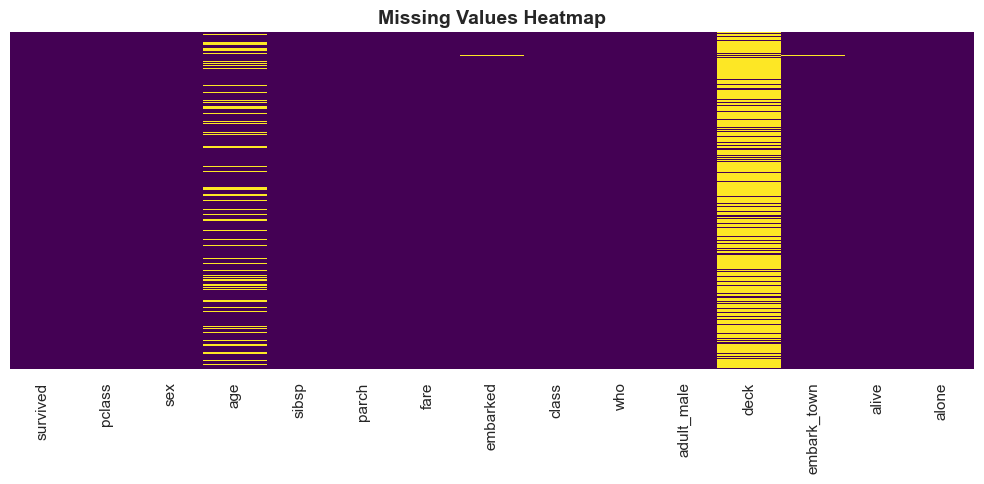

In [16]:
# Visualise missing values
plt.figure(figsize=(10, 5))
sns.heatmap(df.isnull(), cbar=False, yticklabels=False, cmap='viridis')
plt.title('Missing Values Heatmap', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 6. Visualisations

C:\Users\Lenovo\AppData\Local\Temp\ipykernel_36452\1209518710.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(data=df, x='survived', palette=['#e74c3c', '#2ecc71'])
C:\Users\Lenovo\AppData\Local\Temp\ipykernel_36452\1209518710.py:4: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(['Did Not Survive', 'Survived'])


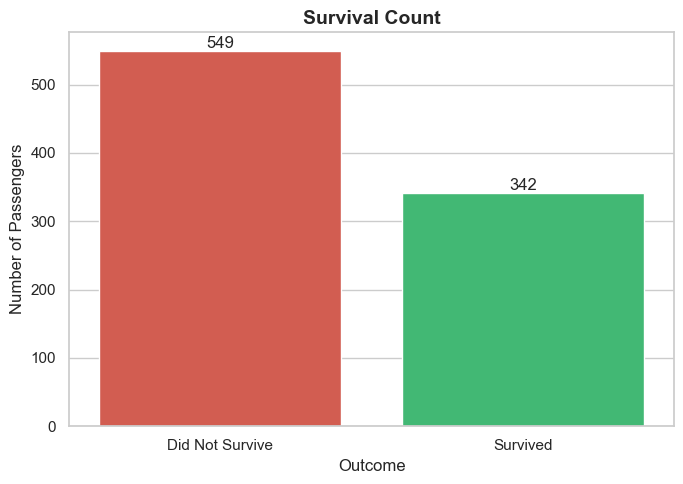

In [17]:
# --- Plot 1: Survival Count ---
plt.figure(figsize=(7, 5))
ax = sns.countplot(data=df, x='survived', palette=['#e74c3c', '#2ecc71'])
ax.set_xticklabels(['Did Not Survive', 'Survived'])
plt.title('Survival Count', fontsize=14, fontweight='bold')
plt.xlabel('Outcome')
plt.ylabel('Number of Passengers')
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom', fontsize=12)
plt.tight_layout()
plt.show()

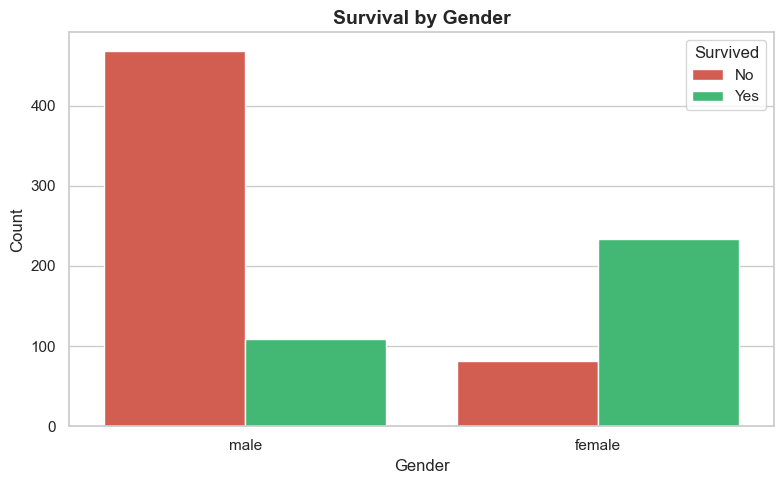

In [18]:
# --- Plot 2: Survival by Gender ---
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='sex', hue='survived', palette=['#e74c3c', '#2ecc71'])
plt.title('Survival by Gender', fontsize=14, fontweight='bold')
plt.xlabel('Gender')
plt.ylabel('Count')
plt.legend(title='Survived', labels=['No', 'Yes'])
plt.tight_layout()
plt.show()

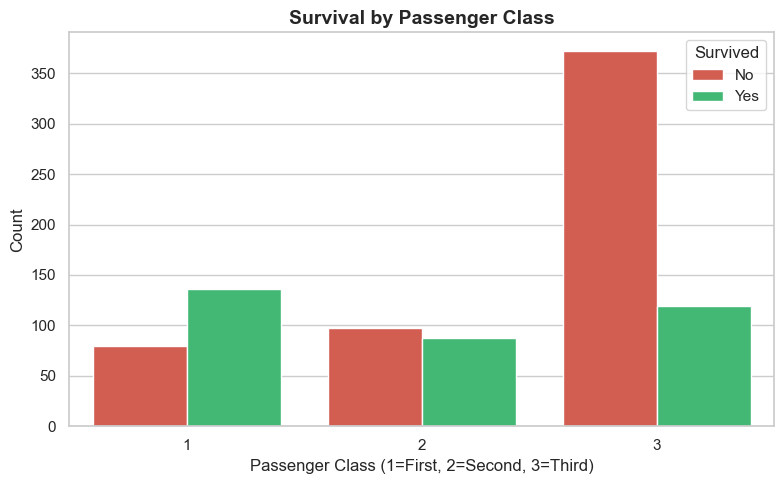

In [19]:
# --- Plot 3: Survival by Passenger Class ---
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='pclass', hue='survived', palette=['#e74c3c', '#2ecc71'])
plt.title('Survival by Passenger Class', fontsize=14, fontweight='bold')
plt.xlabel('Passenger Class (1=First, 2=Second, 3=Third)')
plt.ylabel('Count')
plt.legend(title='Survived', labels=['No', 'Yes'])
plt.tight_layout()
plt.show()

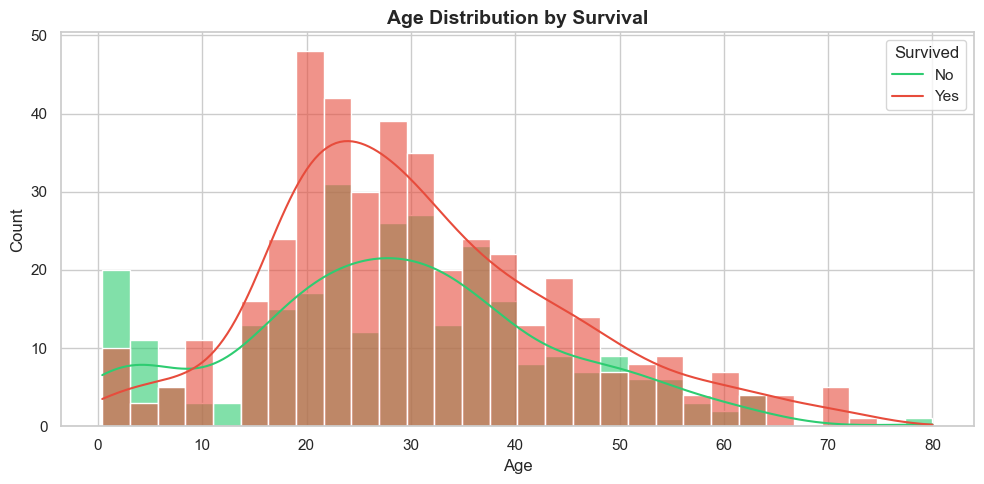

In [20]:
# --- Plot 4: Age Distribution ---
plt.figure(figsize=(10, 5))
sns.histplot(data=df, x='age', hue='survived', bins=30, kde=True,
             palette=['#e74c3c', '#2ecc71'], alpha=0.6)
plt.title('Age Distribution by Survival', fontsize=14, fontweight='bold')
plt.xlabel('Age')
plt.ylabel('Count')
plt.legend(title='Survived', labels=['No', 'Yes'])
plt.tight_layout()
plt.show()

C:\Users\Lenovo\AppData\Local\Temp\ipykernel_36452\529933801.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='pclass', y='fare', palette='Set2')


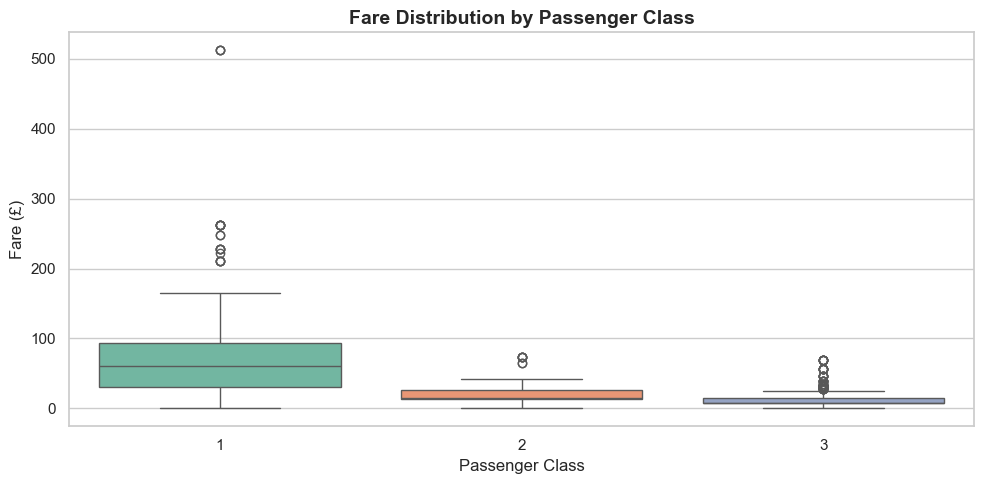

In [21]:
# --- Plot 5: Fare Distribution by Class ---
plt.figure(figsize=(10, 5))
sns.boxplot(data=df, x='pclass', y='fare', palette='Set2')
plt.title('Fare Distribution by Passenger Class', fontsize=14, fontweight='bold')
plt.xlabel('Passenger Class')
plt.ylabel('Fare (£)')
plt.tight_layout()
plt.show()

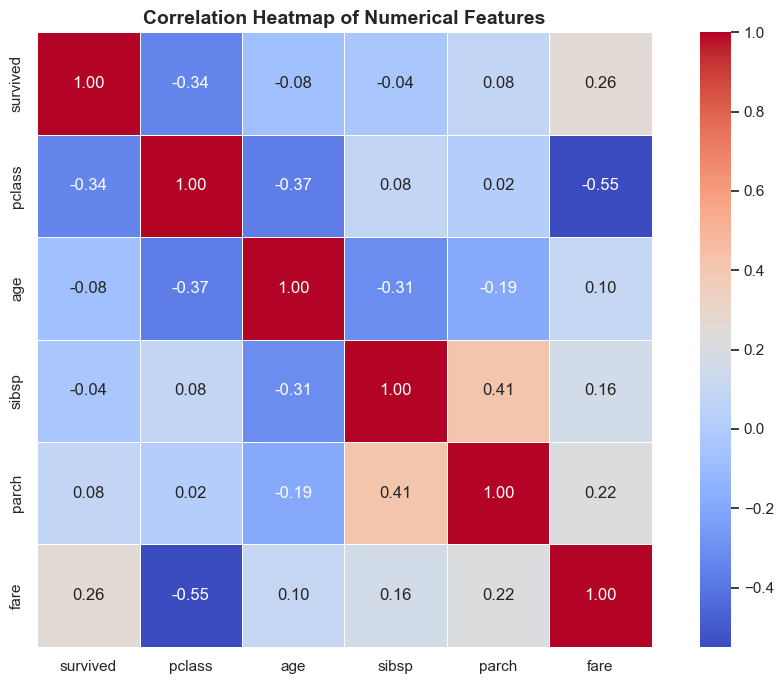

In [22]:
# --- Plot 6: Correlation Heatmap ---
plt.figure(figsize=(10, 7))
corr = df[['survived', 'pclass', 'age', 'sibsp', 'parch', 'fare']].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm',
            square=True, linewidths=0.5)
plt.title('Correlation Heatmap of Numerical Features', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

<Figure size 1000x600 with 0 Axes>

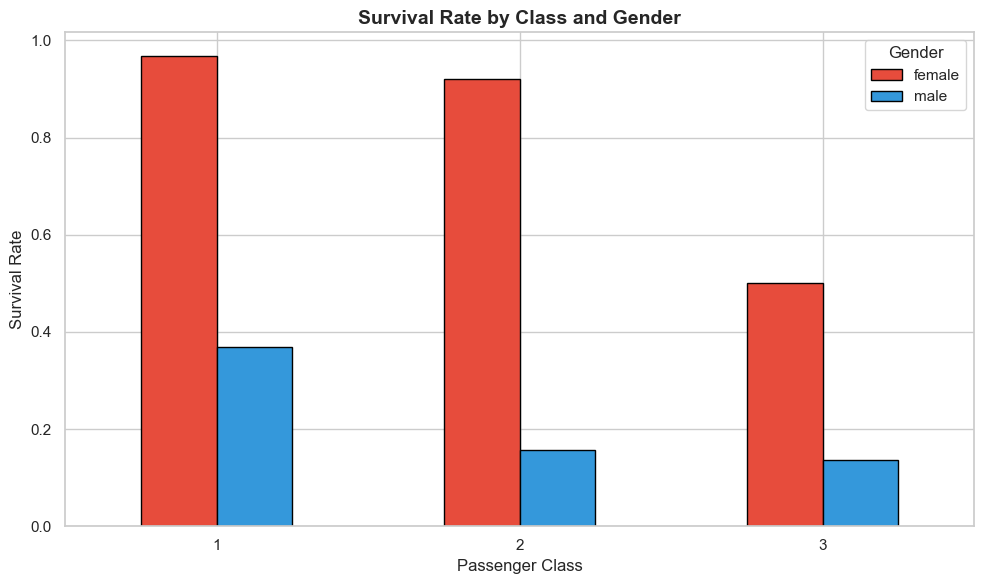

In [23]:
# --- Plot 7: Survival Rate by Class and Gender (Grouped) ---
plt.figure(figsize=(10, 6))
survival_pivot = df.groupby(['pclass', 'sex'])['survived'].mean().unstack()
survival_pivot.plot(kind='bar', color=['#e74c3c', '#3498db'], edgecolor='black')
plt.title('Survival Rate by Class and Gender', fontsize=14, fontweight='bold')
plt.xlabel('Passenger Class')
plt.ylabel('Survival Rate')
plt.xticks(rotation=0)
plt.legend(title='Gender')
plt.tight_layout()
plt.show()

## 7. 📝 Key Insights

Based on the analysis above, here are the key findings from the Titanic dataset:

1. **Overall Survival Rate** Only about 38% of passengers survived the disaster.
2. **Gender** Female passengers had a significantly higher survival rate (74%) compared to males (19%). *"Women and children first"* policy is evident.
3. **Passenger Class**  First-class passengers had the highest survival rate (63%), while 3rd class had the lowest (24%), highlighting socioeconomic inequality.
4. **Age** Children had a relatively higher survival rate. Elderly passengers were less likely to survive.
5. **Fare**  Higher fares (associated with 1st class) correlate with better survival chances.
6. **Missing Data** The `age` column has 20% missing values, and `deck` has over 77% missing, these need to be handled carefully in modeling.
